# Demo: DeepHit Competing Risks (RNN + Transformer)

This notebook trains and evaluates a competing-risks DeepHit model on AAPL limit-order-book samples using a **GRU + Transformer** hybrid backbone.

Input streams:
- LOB features from `entry_representation` with shape (20, 41)
- Toxicity features from `toxicity_representation` plus side and validity mask with shape (20, 20)
- Combined model input shape (20, 61)

Event coding used in this notebook:
| Event | Code |
|------|------|
| CENSORED | 0 |
| FAVORABLE_FILL | 1 |
| TOXIC_FILL | 2 |

Workflow: load data, preprocess, train DeepHit, predict CIFs, and evaluate calibration/ranking metrics.

## 1. Import Required Libraries

In [1]:
from __future__ import annotations

import os
import sys
import warnings
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

from pycox.models import DeepHit
from pycox.preprocessing.label_transforms import LabTransDiscreteTime
from pycox.models.data import pair_rank_mat
from pycox.evaluation import EvalSurv

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

%matplotlib inline
print("PyTorch:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# CPU-only tuning: use available cores efficiently.
if device.type == "cpu":
    cpu_threads = max(1, os.cpu_count() or 1)
    torch.set_num_threads(cpu_threads)
    print(f"CPU threads configured: {cpu_threads}")

PyTorch: 2.10.0+cpu
Device: cpu
CPU threads configured: 8


## 2. Load and Explore the Dataset

The dataset is generated by `OrderTracker.process_stream` and labeled by `ExecutionCompetingRisksLabeler`.  
Key columns:
- **`duration_s`** - continuous lifetime of the virtual order (seconds)
- **`event_type`** - integer from `EventType` enum (0=censored, 1/2=competing events)
- **`entry_representation`** - LOB snapshot sequence `(lookback, 2W+1)` stored as a nested list

In [2]:
import duckdb

DATASET_PATH = PROJECT_ROOT / "data" / "datasets" / "dataset_XNAS_ITCH_AAPL_mbo_20251001_20260101.parquet"

# exclude 'lob_sequence' and 'toxicity_sequence' to save memory
query = f"SELECT * EXCLUDE (lob_sequence, toxicity_sequence) FROM '{DATASET_PATH}'"
df_raw = duckdb.query(query).df()

print("Shape:", df_raw.shape)
print("\nColumns:", list(df_raw.columns))

Shape: (64000, 21)

Columns: ['best_ask_at_entry', 'best_ask_at_post_trade', 'best_bid_at_entry', 'best_bid_at_post_trade', 'duration_s', 'entry_representation', 'entry_time', 'event', 'event_time_bin', 'event_type', 'order_id', 'order_type', 'post_trade_adverse_move_bps', 'post_trade_recorded', 'post_trade_spread_bps', 'price', 'sequence_length', 'side', 'status_reason', 'toxicity_representation', 'volume']


### 2a. Recode Event Types: Competing Fill Risks

We model **two competing risks** for fill outcomes:
- **Event 1 (FAVORABLE_FILL)**: original code `1`
- **Event 2 (TOXIC_FILL)**: original code `2`
- **Censored (0)**: original code `0`

This isolates fill quality by separating favorable and toxic fills in the hazard structure.

In [3]:
# Recode event types for competing-risks setup
df_raw["event_type_competing"] = df_raw["event_type"].copy()

MAX_TIME = 10.0

# Re-censor all uncensored events beyond MAX_TIME at MAX_TIME.
late_uncensored_mask = (df_raw["duration_s"] > MAX_TIME)
n_late_uncensored = int(late_uncensored_mask.sum())
if n_late_uncensored > 0:
    df_raw.loc[late_uncensored_mask, "event_type_competing"] = 0
    df_raw.loc[late_uncensored_mask, "duration_s"] = MAX_TIME

label_map = {
    0: "CENSORED",
    1: "FAVORABLE_FILL",
    2: "TOXIC_FILL",
}

print(f"Late uncensored events re-censored at {MAX_TIME:.0f}s: {n_late_uncensored}")
print("Recoded competing event distribution:")
event_counts = df_raw["event_type_competing"].value_counts().sort_index()
for code in sorted(event_counts.index):
    label = label_map.get(int(code), f"UNKNOWN_{code}")
    print(f"  {code}: {label:<30} - {event_counts[code]:>6} samples")

Late uncensored events re-censored at 10s: 11726
Recoded competing event distribution:
  0: CENSORED                       -  11727 samples
  1: FAVORABLE_FILL                 -  23992 samples
  2: TOXIC_FILL                     -  28281 samples



Duration stats (seconds):
count    64000.000000
mean         3.577520
std          3.706890
min          0.000014
25%          0.536306
50%          1.827708
75%          6.377697
max         10.000000
Name: duration_s, dtype: float64


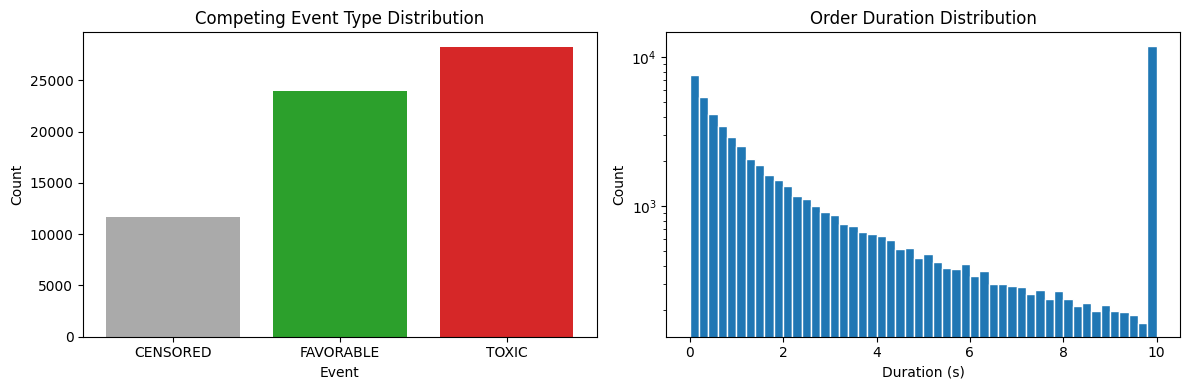

In [4]:
print("\nDuration stats (seconds):")
print(df_raw["duration_s"].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Competing event distribution
event_counts = df_raw["event_type_competing"].value_counts().sort_index()
event_labels = ["CENSORED", "FAVORABLE", "TOXIC"]
bar_vals = [event_counts.get(0, 0), event_counts.get(1, 0), event_counts.get(2, 0)]
colors = ["#aaa", "#2ca02c", "#d62728"]
axes[0].bar(event_labels, bar_vals, color=colors)
axes[0].set_title("Competing Event Type Distribution")
axes[0].set_xlabel("Event")
axes[0].set_ylabel("Count")

# Duration distribution (log scale)
axes[1].hist(df_raw["duration_s"], bins=50, color="#1f77b4", edgecolor="white")
axes[1].set_title("Order Duration Distribution")
axes[1].set_xlabel("Duration (s)")
axes[1].set_ylabel("Count")
axes[1].set_yscale("log")

plt.tight_layout()
plt.show()

## 3. Preprocess the Dataset

### 3a. Feature Extraction: LOB + Toxicity Dual Streams

Both `entry_representation` (LOB snapshots) and `toxicity_representation` (toxicity metrics) are variable-length `(lookback, features)` matrices covering the same temporal window.

**Processing:**
1. Extract LOB features `(N, 20, 41)` and truncate to recent history or left-pad missing steps with zeros
2. Extract toxicity features `(N, 20, 19)`, append side and a validity mask channel → `(N, 20, 21)`
3. Concatenate along feature axis → `(N, 20, 62)` combined LOB+toxicity input
4. Each sample maintains temporal order, with the most recent valid steps aligned to the right

Final feature shape is `(N, 20, 62)`, which is used directly as RNN + Transformer input.

In [5]:
LOOKBACK_STEPS = 20
LOB_FEATURE_DIM = 41
TOX_FEATURE_DIM = 19

def _safe_stack_representation(rep, feat_dim: int) -> np.ndarray:
    """Convert a variable-length nested representation into a 2D float32 array."""
    if rep is None:
        return np.empty((0, feat_dim), dtype=np.float32)

    rows = [np.asarray(row, dtype=np.float32).reshape(-1) for row in rep]
    if len(rows) == 0:
        return np.empty((0, feat_dim), dtype=np.float32)

    arr = np.stack(rows, axis=0)
    if arr.ndim != 2 or arr.shape[1] != feat_dim:
        raise ValueError(
            f"Unexpected representation shape {arr.shape}; expected (*, {feat_dim})."
        )
    return arr


def _left_pad_or_truncate(arr: np.ndarray, lookback_steps: int) -> tuple[np.ndarray, int]:
    """Keep most recent history and left-pad missing steps with zeros."""
    if arr.shape[0] >= lookback_steps:
        arr = arr[-lookback_steps:]
        valid_len = lookback_steps
    else:
        valid_len = arr.shape[0]
        pad_len = lookback_steps - valid_len
        pad = np.zeros((pad_len, arr.shape[1]), dtype=np.float32)
        arr = np.concatenate([pad, arr], axis=0)
    return arr, valid_len


def extract_lob_features(df: pd.DataFrame, lookback_steps: int = LOOKBACK_STEPS) -> np.ndarray:
    """Extract fixed-length LOB features for RNN + Transformer input.

    Returns shape (N, lookback_steps, 41).
    - entry_representation rows are shape (41,)
    - Sequence is truncated to recent history or left-padded with zeros
    """
    rows = []
    for rep in df["entry_representation"]:
        arr_raw = _safe_stack_representation(rep, feat_dim=LOB_FEATURE_DIM)
        arr, _ = _left_pad_or_truncate(arr_raw, lookback_steps=lookback_steps)
        rows.append(arr)

    return np.stack(rows, axis=0)


def extract_toxicity_features(df: pd.DataFrame, lookback_steps: int = LOOKBACK_STEPS) -> np.ndarray:
    """Extract fixed-length toxicity features with side and validity mask.

    Returns shape (N, lookback_steps, 20).
    - toxicity_representation rows are shape (18,)
    - side channel appended (1 dim)
    - validity mask appended (1 dim, 1=real row, 0=left-pad row)
    """
    side_raw = df["side"]
    if np.issubdtype(side_raw.dtype, np.number):
        side_vals = side_raw.astype(np.float32).to_numpy()
    else:
        side_vals = (
            side_raw.astype(str)
            .str.upper()
            .map({"B": 1.0, "A": 0.0})
            .fillna(0.5)
            .astype(np.float32)
            .to_numpy()
        )

    rows = []
    for rep, side_val in zip(df["toxicity_representation"], side_vals):
        arr_raw = _safe_stack_representation(rep, feat_dim=TOX_FEATURE_DIM)
        arr, valid_len = _left_pad_or_truncate(arr_raw, lookback_steps=lookback_steps)

        mask_col = np.zeros((lookback_steps, 1), dtype=np.float32)
        if valid_len > 0:
            mask_col[-valid_len:, 0] = 1.0

        side_col = np.full((lookback_steps, 1), side_val, dtype=np.float32) * mask_col
        arr_with_side_and_mask = np.concatenate([arr, side_col, mask_col], axis=1)
        rows.append(arr_with_side_and_mask)

    return np.stack(rows, axis=0)


# Extract both LOB and toxicity features
X_lob = extract_lob_features(df_raw, lookback_steps=LOOKBACK_STEPS)
X_tox = extract_toxicity_features(df_raw, lookback_steps=LOOKBACK_STEPS)

# Concatenate along feature dimension
X_all = np.concatenate([X_lob, X_tox], axis=2)

Y_all = df_raw["duration_s"].values.astype(np.float32)             # continuous durations (seconds)
D_all = df_raw["event_type_competing"].values.astype(np.int64)      # 0=censored, 1=favorable, 2=toxic

print(f"LOB features shape       : {X_lob.shape}       - (N, lookback=20, LOB_features=41)")
print(f"Toxicity features shape  : {X_tox.shape}       - (N, lookback=20, toxicity_features=20)")
print(f"Combined features shape  : {X_all.shape}     - (N, lookback=20, combined_features=61)")
print(f"Duration vector shape    : {Y_all.shape}")
print(f"Event vector shape       : {D_all.shape}")
print(f"Unique event codes       : {sorted(np.unique(D_all).tolist())}")
print(f"Valid timestep ratio (tox mask): {X_tox[:, :, -1].mean():.4f}")

LOB features shape       : (64000, 20, 41)       - (N, lookback=20, LOB_features=41)
Toxicity features shape  : (64000, 20, 21)       - (N, lookback=20, toxicity_features=20)
Combined features shape  : (64000, 20, 62)     - (N, lookback=20, combined_features=61)
Duration vector shape    : (64000,)
Event vector shape       : (64000,)
Unique event codes       : [0, 1, 2]
Valid timestep ratio (tox mask): 1.0000


### 3b. Train / Validation / Test Split

In [6]:
SEED = 4718

# Day-boundary temporal split
# We extract the trading date for each order and choose the split points
# so that each partition starts cleanly at the beginning of a new day.

entry_ns = df_raw["entry_time"].values
dates = pd.to_datetime(entry_ns, unit="ns", utc=True).tz_convert("America/New_York").normalize()

unique_days = sorted(dates.unique())
n_days = len(unique_days)
print(f"Dataset spans {n_days} trading days: {unique_days[0].date()} to {unique_days[-1].date()}")

# Pick the day boundaries nearest to the 70 / 85 percentile of total rows
n = len(df_raw)
target_train_end = int(n * 0.70)
target_val_end   = int(n * 0.85)

# Cumulative row counts at the END of each day
day_end_idx = [(dates <= d).sum() - 1 for d in unique_days]   # last row index of each day

def _best_day_cut(target_row: int) -> int:
    """Return the index of the day whose END row is closest to target_row."""
    return min(range(n_days), key=lambda i: abs(day_end_idx[i] - target_row))

train_day_idx = _best_day_cut(target_train_end)
val_day_idx   = _best_day_cut(target_val_end)
train_day_idx = min(train_day_idx, n_days - 3)
val_day_idx   = max(train_day_idx + 1, min(val_day_idx, n_days - 2))

train_end = day_end_idx[train_day_idx] + 1
val_end   = day_end_idx[val_day_idx]   + 1

idx = np.arange(n)
train_mask = idx < train_end
val_mask   = (idx >= train_end) & (idx < val_end)
test_mask  = idx >= val_end

X_train, Y_train, D_train = X_all[train_mask], Y_all[train_mask], D_all[train_mask]
X_val,   Y_val,   D_val   = X_all[val_mask],   Y_all[val_mask],   D_all[val_mask]
X_test,  Y_test,  D_test  = X_all[test_mask],  Y_all[test_mask],  D_all[test_mask]

train_days = unique_days[:train_day_idx + 1]
val_days   = unique_days[train_day_idx + 1 : val_day_idx + 1]
test_days  = unique_days[val_day_idx + 1:]

print("Using full temporal splits without train/val subsampling:")
print(f"  Train samples: {len(X_train):,} over {len(train_days)} day(s)")
print(f"  Val samples  : {len(X_val):,} over {len(val_days)} day(s)")
print(f"  Test samples : {len(X_test):,} over {len(test_days)} day(s)")

Dataset spans 64 trading days: 2025-10-01 to 2025-12-31
Using full temporal splits without train/val subsampling:
  Train samples: 45,000 over 45 day(s)
  Val samples  : 9,000 over 9 day(s)
  Test samples : 10,000 over 10 day(s)


### 3c. Feature Normalisation

Standardise each feature using training-set mean and standard deviation (prevents data leakage).
For sequential data `(N, 20, F)`, normalization is applied feature-wise using train statistics over sample and time axes.
The toxicity validity mask feature is kept binary (`0/1`) and is not standardized.


In [7]:
feat_mean = X_train.mean(axis=(0, 1), keepdims=True)  # Average over samples and time
feat_std  = X_train.std(axis=(0, 1), keepdims=True) + 1e-8

# Last feature is toxicity validity mask; keep it binary instead of standardizing.
mask_col_idx = X_train.shape[2] - 1
feat_mean[..., mask_col_idx] = 0.0
feat_std[..., mask_col_idx] = 1.0

X_train_np = ((X_train - feat_mean) / feat_std).astype(np.float32)
X_val_np   = ((X_val   - feat_mean) / feat_std).astype(np.float32)
X_test_np  = ((X_test  - feat_mean) / feat_std).astype(np.float32)

# Preserve exact mask values after normalization.
X_train_np[..., mask_col_idx] = X_train[..., mask_col_idx]
X_val_np[..., mask_col_idx] = X_val[..., mask_col_idx]
X_test_np[..., mask_col_idx] = X_test[..., mask_col_idx]

print(f"Normalized feature range - Train: [{X_train_np.min():.3f}, {X_train_np.max():.3f}]")
print(f"Mask unique values (train): {sorted(np.unique(X_train_np[..., mask_col_idx]).tolist())}")

Normalized feature range - Train: [-106.402, 149.161]
Mask unique values (train): [1.0]


### 3d. Discretise Continuous Durations

Following the reference implementation, we use PyCox's `LabTransDiscreteTime` for quantile-based binning.
Only uncensored events inform the grid construction.

In [8]:
class LabTransform(LabTransDiscreteTime):
    """Extends LabTransDiscreteTime to keep competing event codes (1..K)."""
    def transform(self, durations, events):
        durations, is_event = super().transform(durations, events > 0)
        events = events.astype("int64")
        events[is_event == 0] = 0
        return durations, events


NUM_TIME_STEPS = 30

label_transform = LabTransform(NUM_TIME_STEPS, scheme="quantiles")

Y_train_disc, D_train_disc = label_transform.fit_transform(Y_train.copy(), D_train.copy())
Y_val_disc,   D_val_disc   = label_transform.transform(Y_val.copy(),   D_val.copy())

time_grid = label_transform.cuts
output_steps = len(time_grid)

print(f"Requested time steps : {NUM_TIME_STEPS}")
print(f"Actual time steps    : {output_steps}")
print(f"Time grid (seconds)  : {np.round(time_grid, 3)}")
print(f"Train event codes    : {sorted(np.unique(D_train_disc).tolist())}")

Requested time steps : 30
Actual time steps    : 30
Time grid (seconds)  : [ 0.     0.026  0.057  0.088  0.126  0.167  0.209  0.257  0.311  0.366
  0.43   0.5    0.575  0.657  0.748  0.846  0.96   1.089  1.238  1.407
  1.61   1.844  2.116  2.465  2.87   3.412  4.159  5.204  6.87  10.   ]
Train event codes    : [0, 1, 2]


### 3e. Build PyTorch Datasets

In [9]:
def make_tensors(X_np, Y_disc_np, D_disc_np):
    # RNN input stays as (N, lookback, features).
    X = torch.tensor(X_np, dtype=torch.float32, device=device)
    Y = torch.tensor(Y_disc_np, dtype=torch.int64, device=device)
    D = torch.tensor(D_disc_np, dtype=torch.int64, device=device)
    return X, Y, D


X_train_t, Y_train_t, D_train_t = make_tensors(X_train_np, Y_train_disc, D_train_disc)
X_val_t, Y_val_t, D_val_t = make_tensors(X_val_np, Y_val_disc, D_val_disc)

train_data = list(zip(X_train_t, Y_train_t, D_train_t))
val_data = list(zip(X_val_t, Y_val_t, D_val_t))

print(f"Train tensor: X={tuple(X_train_t.shape)}, Y={tuple(Y_train_t.shape)}, D={tuple(D_train_t.shape)}")
print(f"Val tensor: X={tuple(X_val_t.shape)}, Y={tuple(Y_val_t.shape)}, D={tuple(D_val_t.shape)}")

Train tensor: X=(45000, 20, 62), Y=(45000,), D=(45000,)
Val tensor: X=(9000, 20, 62), Y=(9000,), D=(9000,)


## 4. Define the DeepHit Architecture

The competing-risks DeepHit model uses an **RNN + Transformer hybrid backbone** with dual input streams and outputs a joint cause-time tensor:
- **Dual input streams**: Concatenated LOB + toxicity features `(batch, 20, 61)`
  - LOB microstructure (41 features)
  - Toxicity metrics (20 features, including side and validity mask)
- **Sequence encoder**: GRU to capture local temporal dynamics, followed by a Transformer encoder for global temporal interactions
- **Survival output**: `(batch, K, T)` where `K=2` competing events and `T` is discrete time steps
- **Event heads**: `FAVORABLE_FILL` and `TOXIC_FILL`

PyCox's `DeepHit` applies a joint softmax over the `K x T` logits to form a joint PMF over `(cause, time)` and derives cause-specific CIFs from that PMF.

## 5. Configure Training Parameters

In [10]:
# Hyperparameters
NUM_COMPETING_EVENTS = 2
EVENT_NAMES = ["FAVORABLE_FILL", "TOXIC_FILL"]
EVENT_CODES = [1, 2]

CPU_QUICK_MODE = device.type == "cpu"

# RNN + Transformer Architecture (fixed 20-step lookback window)
RNN_HIDDEN_SIZE = 128 if CPU_QUICK_MODE else 160
RNN_NUM_LAYERS = 2
RNN_DROPOUT = 0.2

TRANSFORMER_NUM_LAYERS = 2
TRANSFORMER_NUM_HEADS = 8
TRANSFORMER_FF_DIM = 2 * RNN_HIDDEN_SIZE
TRANSFORMER_DROPOUT = 0.1

FC_DROPOUT = 0.2

# DeepHit loss
ALPHA = 0.5
SIGMA = 0.1

# Optimisation
LEARNING_RATE = 5e-4
BATCH_SIZE = 512 if CPU_QUICK_MODE else 1024
NUM_EPOCHS = 100
EARLY_STOP_PATIENCE = 12

print("Configuration:")
for k, v in {
    "Competing events": NUM_COMPETING_EVENTS,
    "Event names": EVENT_NAMES,
    "Lookback steps": LOOKBACK_STEPS,
    "RNN hidden size": RNN_HIDDEN_SIZE,
    "RNN layers": RNN_NUM_LAYERS,
    "RNN dropout": RNN_DROPOUT,
    "Transformer layers": TRANSFORMER_NUM_LAYERS,
    "Transformer heads": TRANSFORMER_NUM_HEADS,
    "Transformer FF dim": TRANSFORMER_FF_DIM,
    "Transformer dropout": TRANSFORMER_DROPOUT,
    "LR": LEARNING_RATE,
    "Batch size": BATCH_SIZE,
    "Epochs": NUM_EPOCHS,
    "Early stop patience": EARLY_STOP_PATIENCE,
}.items():

    print(f"  {k:<22}: {v}")

Configuration:
  Competing events      : 2
  Event names           : ['FAVORABLE_FILL', 'TOXIC_FILL']
  Lookback steps        : 20
  RNN hidden size       : 128
  RNN layers            : 2
  RNN dropout           : 0.2
  Transformer layers    : 2
  Transformer heads     : 8
  Transformer FF dim    : 256
  Transformer dropout   : 0.1
  LR                    : 0.0005
  Batch size            : 512
  Epochs                : 100
  Early stop patience   : 12


### 5a. Build Competing-Risks RNN + Transformer

Define a hybrid backbone that combines:

- **GRU sequence features**: local temporal encoding over the 20-step window
- **Transformer encoder**: self-attention over GRU outputs to model long-range temporal dependencies
- **Survival logits**: shape `(batch, K, T)` for DeepHit competing risks (`K=2` fill outcomes, `T` time bins)

In [11]:
torch.manual_seed(SEED)

class DeepHitRNNTransformerCompeting(nn.Module):
    """GRU + Transformer backbone for DeepHit competing risks.

    Input shape:  (batch, lookback_steps, num_features)
    num_features = 61 (41 LOB + 20 toxicity features)
    Output shape: (batch, num_events, num_time_steps)
    """

    def __init__(
        self,
        num_features: int,
        num_events: int,
        num_time_steps: int,
        hidden_size: int = 160,
        num_layers: int = 2,
        rnn_dropout: float = 0.2,
        transformer_layers: int = 2,
        transformer_heads: int = 8,
        transformer_ff_dim: int = 320,
        transformer_dropout: float = 0.1,
        max_seq_len: int = 20,
        fc_dropout: float = 0.2,
    ):
        super().__init__()
        self.num_events = num_events
        self.num_time_steps = num_time_steps
        self.max_seq_len = max_seq_len

        if hidden_size % transformer_heads != 0:
            raise ValueError("hidden_size must be divisible by transformer_heads.")

        self.rnn = nn.GRU(
            input_size=num_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=rnn_dropout if num_layers > 1 else 0.0,
            bidirectional=False,
        )

        self.positional_embedding = nn.Parameter(
            torch.zeros(1, max_seq_len, hidden_size)
        )
        nn.init.normal_(self.positional_embedding, mean=0.0, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_size,
            nhead=transformer_heads,
            dim_feedforward=transformer_ff_dim,
            dropout=transformer_dropout,
            activation="gelu",
            batch_first=True,
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=transformer_layers,
        )
        self.pre_transformer_norm = nn.LayerNorm(hidden_size)

        fc_hidden = 128 if CPU_QUICK_MODE else 256

        # Survival head for DeepHit.
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, fc_hidden),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(fc_hidden),
            nn.Dropout(fc_dropout),
            nn.Linear(fc_hidden, num_events * num_time_steps),
        )

        self.latest_transformer_output = None

    def forward(self, x: torch.Tensor):
        # Left-padding convention: padded prefix at the beginning, valid steps aligned to the right.
        seq_lens = x[:, :, -1].sum(dim=1).long().clamp(min=1)
        seq_len = x.size(1)

        if seq_len > self.max_seq_len:
            raise ValueError(
                f"Sequence length {seq_len} exceeds max_seq_len={self.max_seq_len}."
            )

        # Run GRU directly on left-padded sequences.
        rnn_out, _ = self.rnn(x)

        tr_in = self.pre_transformer_norm(
            rnn_out + self.positional_embedding[:, :seq_len, :]
        )

        # Build padding mask for transformer: True = padded position (ignored by attention).
        positions = torch.arange(seq_len, device=x.device).unsqueeze(0)  # (1, L)
        pad_lens = seq_len - seq_lens.unsqueeze(1)                        # (B, 1)
        padding_mask = positions < pad_lens                               # (B, L) True=padded

        tr_out = self.transformer(tr_in, src_key_padding_mask=padding_mask)

        last_token = tr_out[:, -1, :]
        # Masked mean pool: exclude padded positions to avoid noise from zero-filled outputs.
        valid_mask_f = (~padding_mask).float().unsqueeze(-1)  # (B, L, 1)
        mean_token = (tr_out * valid_mask_f).sum(dim=1) / valid_mask_f.sum(dim=1).clamp(min=1)
        seq_repr = torch.cat([last_token, mean_token], dim=-1)

        self.latest_transformer_output = tr_out
        return self.fc(seq_repr).view(x.size(0), self.num_events, self.num_time_steps)


feature_dim = X_train_t.size(2)

base_net = DeepHitRNNTransformerCompeting(
    num_features=feature_dim,
    num_events=NUM_COMPETING_EVENTS,
    num_time_steps=output_steps,
    hidden_size=RNN_HIDDEN_SIZE,
    num_layers=RNN_NUM_LAYERS,
    rnn_dropout=RNN_DROPOUT,
    transformer_layers=TRANSFORMER_NUM_LAYERS,
    transformer_heads=TRANSFORMER_NUM_HEADS,
    transformer_ff_dim=TRANSFORMER_FF_DIM,
    transformer_dropout=TRANSFORMER_DROPOUT,
    max_seq_len=X_train_t.size(1),
    fc_dropout=FC_DROPOUT,
).to(device)

deephit_model = DeepHit(
    base_net,
    alpha=ALPHA,
    sigma=SIGMA,
    device=device,
    duration_index=time_grid,
 )

total_params = sum(p.numel() for p in base_net.parameters() if p.requires_grad)
print(f"Input shape      : {tuple(X_train_t.shape)}")
print(f"Lookback steps   : {X_train_t.size(1)}")
print(f"Feature dim      : {feature_dim} (41 LOB + 20 toxicity)")
print(f"Output (K, T)    : ({NUM_COMPETING_EVENTS}, {output_steps})")
print(f"Trainable params : {total_params:,}")

Input shape      : (45000, 20, 62)
Lookback steps   : 20
Feature dim      : 62 (41 LOB + 20 toxicity)
Output (K, T)    : (2, 30)
Trainable params : 481,468


In [12]:
print(f"{'Layer Name (Type)':<50} {'Weight Shape':<25} {'Param #':<15}")
print("=" * 90)

total_params = 0
trainable_params = 0

# Iterate through all modules in the network
for name, module in base_net.named_modules():
    # Only process modules that have direct parameters (recurse=False prevents double counting)
    params = list(module.parameters(recurse=False))
    if not params:
        continue
        
    layer_type = module.__class__.__name__
    display_name = f"{name} ({layer_type})" if name else layer_type
    
    # Calculate parameters for this specific layer
    layer_params = sum(p.numel() for p in params)
    layer_trainable = sum(p.numel() for p in params if p.requires_grad)
    
    total_params += layer_params
    trainable_params += layer_trainable
    
    # Get the shape of the primary weight tensor for display
    weight_shape = str(list(params[0].shape))
    
    # Truncate long names to keep the table clean
    if len(display_name) > 48:
        display_name = "..." + display_name[-45:]
        
    print(f"{display_name:<50} {weight_shape:<25} {layer_params:<15,}")

print("=" * 90)
print(f"Total params    : {total_params:,}")
print(f"Trainable params: {trainable_params:,}")
print(f"Non-trainable   : {total_params - trainable_params:,}")
print(f"Input shape     : (batch, {X_train_t.size(1)}, {X_train_t.size(2)})")
print("-" * 90)

Layer Name (Type)                                  Weight Shape              Param #        
DeepHitRNNTransformerCompeting                     [1, 20, 128]              2,560          
rnn (GRU)                                          [384, 62]                 172,800        
...ormer.layers.0.self_attn (MultiheadAttention)   [384, 128]                49,536         
...tn.out_proj (NonDynamicallyQuantizableLinear)   [128, 128]                16,512         
transformer.layers.0.linear1 (Linear)              [256, 128]                33,024         
transformer.layers.0.linear2 (Linear)              [128, 256]                32,896         
transformer.layers.0.norm1 (LayerNorm)             [128]                     256            
transformer.layers.0.norm2 (LayerNorm)             [128]                     256            
...ormer.layers.1.self_attn (MultiheadAttention)   [384, 128]                49,536         
...tn.out_proj (NonDynamicallyQuantizableLinear)   [128, 128]         

## 6. Train the DeepHit Model

Training uses mini-batch gradient descent with the DeepHit competing-risks loss.  
Model parameters from the epoch with the **lowest validation loss** are retained.

In [13]:
# Remove stale forward hooks that may remain after a failed model summary call.
def _clear_forward_hooks(model: nn.Module) -> None:
    for module in model.modules():
        module._forward_hooks.clear()
        module._forward_pre_hooks.clear()

_clear_forward_hooks(base_net)

# Data loading tuned for CPU/GPU differences.
if device.type == "cpu":
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=False)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=False)
else:
    train_loader = DataLoader(train_data, BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
    val_loader = DataLoader(val_data, BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

optimizer = torch.optim.Adam(base_net.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=NUM_EPOCHS, eta_min=LEARNING_RATE * 0.1
)

train_losses, val_losses = [], []
best_val_loss = float("inf")
best_params = None
best_epoch_idx = None
epochs_no_improve = 0

# Training loop with early stopping.
for epoch in range(NUM_EPOCHS):
    base_net.train()
    epoch_loss = 0.0
    n_batches = 0

    for X_b, Y_b, D_b in train_loader:
        optimizer.zero_grad()

        surv_logits = base_net(X_b)

        rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
        rm_t = torch.tensor(rm, dtype=torch.int, device=device)
        loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_loss = epoch_loss / n_batches

    base_net.eval()
    val_loss_total = 0.0
    n_val_batches = 0

    with torch.no_grad():
        for X_b, Y_b, D_b in val_loader:
            surv_logits = base_net(X_b)

            rm = pair_rank_mat(Y_b.cpu().numpy(), D_b.cpu().numpy())
            rm_t = torch.tensor(rm, dtype=torch.int, device=device)
            loss = deephit_model.loss(surv_logits, Y_b, D_b, rm_t)

            val_loss_total += loss.item()
            n_val_batches += 1

    val_loss = val_loss_total / n_val_batches

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    scheduler.step()

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch_idx = epoch
        best_params = deepcopy(base_net.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if (epoch + 1) % 2 == 0:
        print(
            f"Epoch {epoch+1:>3}/{NUM_EPOCHS}  "
            f"train={train_loss:.4f}  val={val_loss:.4f}  "
            f"(no improve: {epochs_no_improve})"
        )

    if epochs_no_improve >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} (val loss did not improve for {EARLY_STOP_PATIENCE} epochs)")
        break

base_net.load_state_dict(best_params)
print(f"\nBest val loss {best_val_loss:.4f} at epoch {best_epoch_idx + 1}")

c:\Users\AngusCheung\anaconda3\envs\lob\Lib\site-packages\torch\nn\modules\transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\NestedTensorImpl.cpp:182.)
  output = torch._nested_tensor_from_mask(


Epoch   2/100  train=2.2757  val=2.2467  (no improve: 0)
Epoch   4/100  train=2.2091  val=2.1961  (no improve: 0)
Epoch   6/100  train=2.1622  val=2.1781  (no improve: 0)
Epoch   8/100  train=2.1294  val=2.1665  (no improve: 0)
Epoch  10/100  train=2.1090  val=2.1418  (no improve: 0)
Epoch  12/100  train=2.0900  val=2.1343  (no improve: 0)
Epoch  14/100  train=2.0724  val=2.1513  (no improve: 2)
Epoch  16/100  train=2.0563  val=2.1365  (no improve: 1)
Epoch  18/100  train=2.0420  val=2.1451  (no improve: 3)
Epoch  20/100  train=2.0263  val=2.1519  (no improve: 5)
Epoch  22/100  train=2.0103  val=2.1629  (no improve: 7)
Epoch  24/100  train=1.9903  val=2.1815  (no improve: 9)


KeyboardInterrupt: 

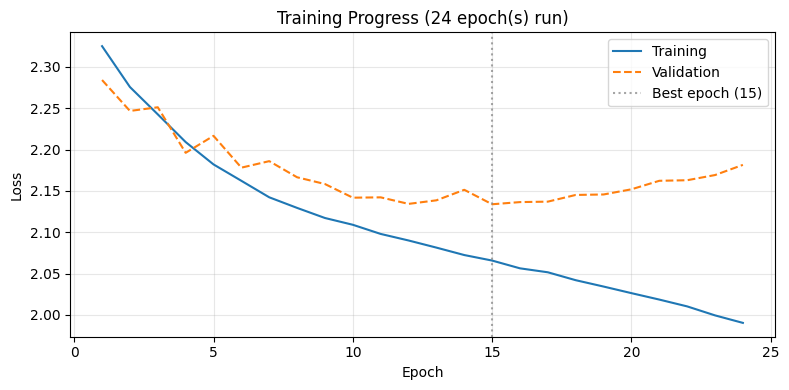


Best epoch 15:
  Train loss: 2.0657
  Val loss  : 2.1338


In [14]:
num_epochs_ran = min(len(train_losses), len(val_losses))
if num_epochs_ran == 0:
    raise RuntimeError("No training history found. Run training cell first.")

epochs = range(1, num_epochs_ran + 1)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(epochs, train_losses[:num_epochs_ran], label="Training", color="#1f77b4")
ax.plot(epochs, val_losses[:num_epochs_ran], "--", label="Validation", color="#ff7f0e")

best_epoch_display = (best_epoch_idx + 1) if best_epoch_idx is not None else None
if best_epoch_display is not None and 1 <= best_epoch_display <= num_epochs_ran:
    ax.axvline(
        best_epoch_display,
        color="grey",
        linestyle=":",
        alpha=0.7,
        label=f"Best epoch ({best_epoch_display})",
    )

ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title(f"Training Progress ({num_epochs_ran} epoch(s) run)")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

best_idx = best_epoch_idx if best_epoch_idx is not None else num_epochs_ran - 1
print(f"\nBest epoch {best_epoch_display}:")
print(f"  Train loss: {train_losses[best_idx]:.4f}")
print(f"  Val loss  : {val_losses[best_idx]:.4f}")

In [15]:
# Save the trained model and metadata to artifacts/baseline
artifact_dir = PROJECT_ROOT / "artifacts" / "baseline"
artifact_dir.mkdir(parents=True, exist_ok=True)

model_save_path = artifact_dir / "static_deephit_rnn_transformer_base_net.pt"
torch.save(base_net.state_dict(), model_save_path)

meta_save_path = artifact_dir / "static_deephit_rnn_transformer_meta.pt"
metadata = {
    "model_name": "RNN-Transformer DeepHit",
    "num_competing_events": NUM_COMPETING_EVENTS,
    "event_names": EVENT_NAMES,
    "output_steps": output_steps,
    "time_grid": time_grid,
    "lookback_steps": LOOKBACK_STEPS,
    "learning_rate": LEARNING_RATE,
    "best_epoch": best_epoch_idx + 1 if best_epoch_idx is not None else None,
    "best_val_loss": best_val_loss,
}
torch.save(metadata, meta_save_path)

print(f"Model saved to: {model_save_path}")
print(f"Metadata saved to: {meta_save_path}")

Model saved to: C:\Users\AngusCheung\OneDrive\PycharmProjects\lob-deep-survival-analysis\artifacts\baseline\static_deephit_rnn_transformer_base_net.pt
Metadata saved to: C:\Users\AngusCheung\OneDrive\PycharmProjects\lob-deep-survival-analysis\artifacts\baseline\static_deephit_rnn_transformer_meta.pt


## Save Model Artifacts

## 7. Evaluate Model Performance

### 7a. Predict Cause-Specific CIFs on the Test Set

`deephit_model.predict_cif` returns an array of shape `(K, T, N)` where:
- `K` = number of competing events (`2`: favorable, toxic)
- `T` = discrete time steps
- `N` = number of test samples

In [16]:
base_net.eval()

# cif_test shape: (K, T, N_test)
cif_test = deephit_model.predict_cif(
    X_test_np.astype("float32"),
    batch_size=BATCH_SIZE,
    to_cpu=True,
    numpy=True,
)

print(f"CIF array shape: {cif_test.shape}   (K=events, T=time_steps, N=test_samples)")
print(f"CIF range: [{cif_test.min():.4f}, {cif_test.max():.4f}]")

print(f"\nFor test sample 0 at t={time_grid[-1]:.1f}s:")
total_fill_prob = 0.0
for k, name in enumerate(EVENT_NAMES):
    p = float(cif_test[k, -1, 0])
    total_fill_prob += p
    print(f"  CIF({name}) = {p:.4f}")
print(f"  CIF(ANY_FILL) = {total_fill_prob:.4f}")
print(f"  Survival      = {1.0 - total_fill_prob:.4f}")

CIF array shape: (2, 30, 10000)   (K=events, T=time_steps, N=test_samples)
CIF range: [0.0000, 0.6580]

For test sample 0 at t=10.0s:
  CIF(FAVORABLE_FILL) = 0.3673
  CIF(TOXIC_FILL) = 0.4692
  CIF(ANY_FILL) = 0.8365
  Survival      = 0.1635


### 7b. Distribution of Predicted Cause-Specific Fill Probabilities

Compare final-time CIF predictions for favorable and toxic risks across true outcome groups.

Test set composition:
  CENSORED      : 2696
  FAVORABLE_FILL: 3370
  TOXIC_FILL    : 3934

Predicted final CIF means at t=10.0s:
  True FAVORABLE -> CIF(FAVORABLE): 0.4029
  True TOXIC     -> CIF(TOXIC)    : 0.4592


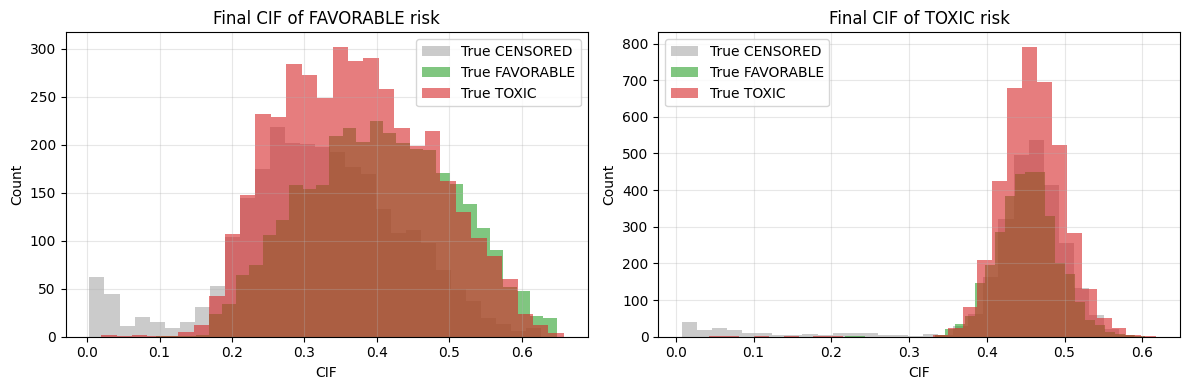

In [17]:
# Final-time cause-specific probabilities
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]

mask_cens = (D_test == 0)
mask_fav = (D_test == 1)
mask_tox = (D_test == 2)

print("Test set composition:")
print(f"  CENSORED      : {int(mask_cens.sum())}")
print(f"  FAVORABLE_FILL: {int(mask_fav.sum())}")
print(f"  TOXIC_FILL    : {int(mask_tox.sum())}")

print(f"\nPredicted final CIF means at t={time_grid[-1]:.1f}s:")
print(f"  True FAVORABLE -> CIF(FAVORABLE): {final_cif_fav[mask_fav].mean():.4f}")
print(f"  True TOXIC     -> CIF(TOXIC)    : {final_cif_tox[mask_tox].mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Favorable-risk distribution
axes[0].hist(final_cif_fav[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[0].hist(final_cif_fav[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[0].hist(final_cif_fav[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[0].set_title("Final CIF of FAVORABLE risk")
axes[0].set_xlabel("CIF")
axes[0].set_ylabel("Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Toxic-risk distribution
axes[1].hist(final_cif_tox[mask_cens], bins=30, alpha=0.5, label="True CENSORED", color="#999999")
axes[1].hist(final_cif_tox[mask_fav], bins=30, alpha=0.6, label="True FAVORABLE", color="#2ca02c")
axes[1].hist(final_cif_tox[mask_tox], bins=30, alpha=0.6, label="True TOXIC", color="#d62728")
axes[1].set_title("Final CIF of TOXIC risk")
axes[1].set_xlabel("CIF")
axes[1].set_ylabel("Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7c. Cause-Specific Concordance

Compute time-dependent concordance for each competing event by treating the other event as censoring for that cause-specific evaluation.

In [18]:
print("Time-dependent Concordance Index (Antolini) per competing event:")

ctd_scores = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    one_minus_cif_df = pd.DataFrame(
        1 - cif_test[k, :, :],
        index=time_grid,
    )

    ev = EvalSurv(
        one_minus_cif_df,
        Y_test,
        (D_test == event_code).astype(int),
        censor_surv="km",
    )

    ctd = ev.concordance_td("antolini")
    ctd_scores[event_name] = ctd
    print(f"  {event_name:<20}: C-td = {ctd:.4f}")

macro_ctd = float(np.mean(list(ctd_scores.values())))
print(f"\nMacro-average C-td: {macro_ctd:.4f}")

Time-dependent Concordance Index (Antolini) per competing event:
  FAVORABLE_FILL      : C-td = 0.6621
  TOXIC_FILL          : C-td = 0.5854

Macro-average C-td: 0.6238


### 7d. Integrated Brier Score

Evaluate calibration with:
- **Per-cause standard Brier score** using binary labels `1{T <= t, D = k}` vs `CIF_k(t)`
- **Multi-class Brier score** over states `[survival, cause_1, ..., cause_K]`

IBS is computed by trapezoidal integration over the available grid interval `[time_grid[0], time_grid[-1]]` (negligible-censoring assumption).

Training event proportions (for uninformed baseline):
  P(FAVORABLE_FILL) = 0.3801
  P(TOXIC_FILL)     = 0.4537
  P(CENSORED)       = 0.1662
  FAVORABLE_FILL      : BS range [0.0000, 0.2130]
  TOXIC_FILL          : BS range [0.0000, 0.2391]

Integrated Brier Score (IBS) per event:
  FAVORABLE_FILL      : IBS = 0.1704  |  Uninformed = 0.2036
  TOXIC_FILL          : IBS = 0.2017  |  Uninformed = 0.2336

Macro-average IBS: 0.1861
Macro-average IBS (uninformed baseline): 0.2186


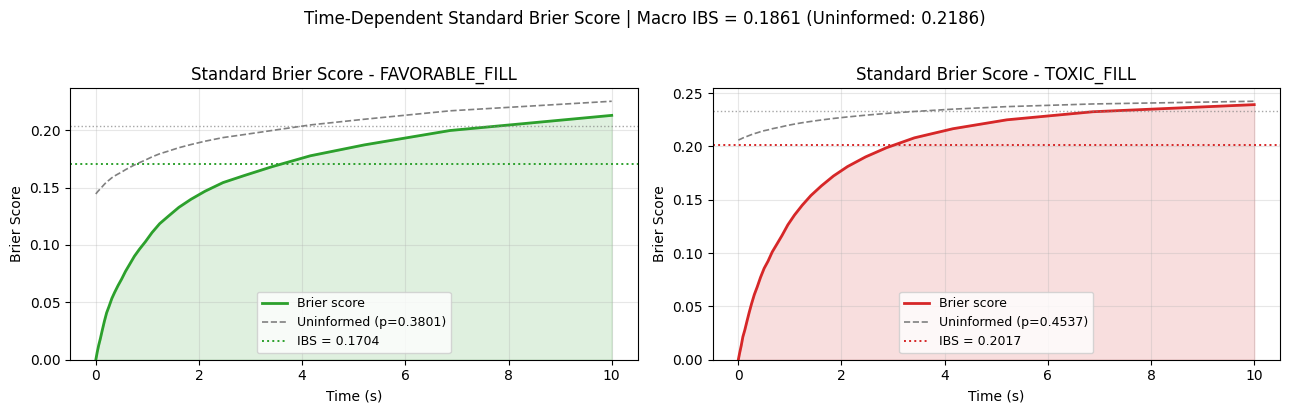

In [19]:
def standard_brier_score(
    durations: np.ndarray,
    events: np.ndarray,
    cif_k: np.ndarray,
    event_code: int,
    time_grid: np.ndarray,
) -> np.ndarray:
    """Compute standard Brier score for a specific cause at each time point."""
    T = len(time_grid)
    bs = np.zeros(T)

    for j, t in enumerate(time_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        residual = (label - cif_k[j, :]) ** 2
        bs[j] = np.mean(residual)

    return bs

# Calculate training event proportions for uninformed baseline
n_train = len(D_train)
p_fav_train = (D_train == 1).sum() / n_train
p_tox_train = (D_train == 2).sum() / n_train

print("Training event proportions (for uninformed baseline):")
print(f"  P(FAVORABLE_FILL) = {p_fav_train:.4f}")
print(f"  P(TOXIC_FILL)     = {p_tox_train:.4f}")
print(f"  P(CENSORED)       = {1.0 - p_fav_train - p_tox_train:.4f}")

# Compute Brier score curves for each event.
bs_curves = {}
for k, (event_code, event_name) in enumerate(zip(EVENT_CODES, EVENT_NAMES)):
    bs_curves[event_name] = standard_brier_score(
        durations=Y_test,
        events=D_test,
        cif_k=cif_test[k],
        event_code=event_code,
        time_grid=time_grid,
)
    print(f"  {event_name:<20}: BS range [{bs_curves[event_name].min():.4f}, {bs_curves[event_name].max():.4f}]")

# Compute uninformed baseline Brier scores (constant predictions based on training proportions)
def uninformed_brier_score(
    durations: np.ndarray,
    events: np.ndarray,
    predicted_prob: float,
    event_code: int,
    time_grid: np.ndarray,
) -> np.ndarray:
    """Compute Brier score for an uninformed model predicting constant probability."""
    T = len(time_grid)
    bs_uninf = np.zeros(T)

    for j, t in enumerate(time_grid):
        label = ((durations <= t) & (events == event_code)).astype(float)
        residual = (label - predicted_prob) ** 2
        bs_uninf[j] = np.mean(residual)

    return bs_uninf

# Generate uninformed baseline curves based on training proportions
bs_curves_uninformed = {}
bs_curves_uninformed["FAVORABLE_FILL"] = uninformed_brier_score(
    Y_test, D_test, p_fav_train, 1, time_grid
)
bs_curves_uninformed["TOXIC_FILL"] = uninformed_brier_score(
    Y_test, D_test, p_tox_train, 2, time_grid
)

# Integrated Brier score (IBS) via trapezoidal integration.
t_min, t_max = time_grid[0], time_grid[-1]
_trapz = np.trapezoid if hasattr(np, "trapezoid") else np.trapz

ibs_scores = {}
ibs_scores_uninformed = {}
for event_name, bs_arr in bs_curves.items():
    ibs_scores[event_name] = _trapz(bs_arr, time_grid) / (t_max - t_min)
    ibs_scores_uninformed[event_name] = _trapz(bs_curves_uninformed[event_name], time_grid) / (t_max - t_min)

macro_ibs = float(np.mean(list(ibs_scores.values())))
macro_ibs_uninformed = float(np.mean(list(ibs_scores_uninformed.values())))

print("\nIntegrated Brier Score (IBS) per event:")
for event_name, ibs in ibs_scores.items():
    ibs_uninf = ibs_scores_uninformed[event_name]
    print(f"  {event_name:<20}: IBS = {ibs:.4f}  |  Uninformed = {ibs_uninf:.4f}")
print(f"\nMacro-average IBS: {macro_ibs:.4f}")
print(f"Macro-average IBS (uninformed baseline): {macro_ibs_uninformed:.4f}")

colors_bs = {"FAVORABLE_FILL": "#2ca02c", "TOXIC_FILL": "#d62728"}
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, (event_name, bs_arr) in zip(axes, bs_curves.items()):
    ibs_val = ibs_scores[event_name]
    ibs_uninf_val = ibs_scores_uninformed[event_name]
    color = colors_bs.get(event_name, "#1f77b4")

    ax.plot(time_grid, bs_arr, color=color, linewidth=2, label="Brier score")
    ax.fill_between(time_grid, bs_arr, alpha=0.15, color=color)
    ax.plot(time_grid, bs_curves_uninformed[event_name], color="grey", linestyle="--", linewidth=1.2, label=f"Uninformed (p={[p_fav_train, p_tox_train][EVENT_NAMES.index(event_name)]:.4f})")
    ax.axhline(ibs_uninf_val, color="grey", linestyle=":", linewidth=1, alpha=0.7)
    ax.axhline(ibs_val, color=color, linestyle=":", linewidth=1.4, label=f"IBS = {ibs_val:.4f}")
    ax.set_title(f"Standard Brier Score - {event_name}")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Brier Score")
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

fig.suptitle(f"Time-Dependent Standard Brier Score | Macro IBS = {macro_ibs:.4f} (Uninformed: {macro_ibs_uninformed:.4f})", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

### 7e. Visualize Competing CIFs for Sample Orders

Plot favorable-risk CIF, toxic-risk CIF, and implied survival for sample test orders.

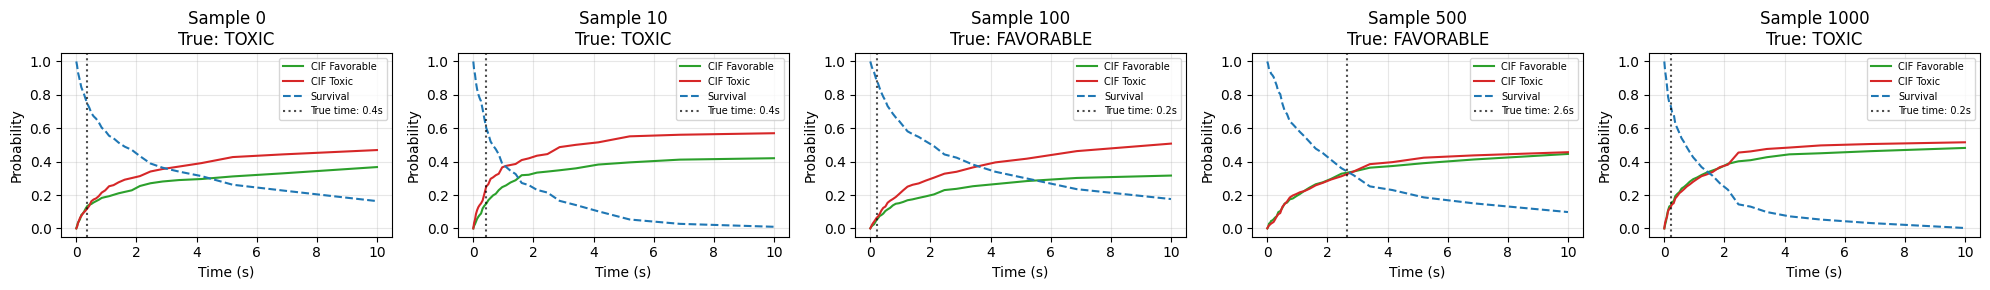

In [20]:
# Select a few sample orders to visualize
sample_indices = [0, 10, 100, 500, 1000]
sample_indices = [i for i in sample_indices if i < len(X_test)]

fig, axes = plt.subplots(1, len(sample_indices), figsize=(4 * len(sample_indices), 3))
if len(sample_indices) == 1:
    axes = [axes]

for ax, idx in zip(axes, sample_indices):
    cif_fav = cif_test[0, :, idx]
    cif_tox = cif_test[1, :, idx]
    surv_curve = 1.0 - (cif_fav + cif_tox)

    true_time = Y_test[idx]
    true_event = int(D_test[idx])
    if true_event == 1:
        true_label = "FAVORABLE"
    elif true_event == 2:
        true_label = "TOXIC"
    else:
        true_label = "CENSORED"

    ax.plot(time_grid, cif_fav, label="CIF Favorable", color="#2ca02c")
    ax.plot(time_grid, cif_tox, label="CIF Toxic", color="#d62728")
    ax.plot(time_grid, surv_curve, label="Survival", color="#1f77b4", linestyle="--")
    ax.axvline(true_time, color="black", linestyle=":", alpha=0.7, label=f"True time: {true_time:.1f}s")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Probability")
    ax.set_title(f"Sample {idx}\nTrue: {true_label}")
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7f. Event Classification Metrics and Stratified CIFs

Report event-classification quality (accuracy, precision, F1) using final-time probabilities, then compare average favorable/toxic CIF curves across true outcome groups.

In [21]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

proba_event = np.vstack([final_surv, final_cif_fav, final_cif_tox]).T  # (N, 3)
y_true = D_test.astype(int)
y_pred = proba_event.argmax(axis=1).astype(int)

In [22]:
# Final-time CIF diagnostics for event classification and censoring behavior.
final_cif_fav = cif_test[0, -1, :]
final_cif_tox = cif_test[1, -1, :]
final_surv = np.clip(1.0 - (final_cif_fav + final_cif_tox), 0.0, 1.0)

# 1) Event-only classification: FAVORABLE vs TOXIC (exclude censored).
has_event_mask = (y_true == 1) | (y_true == 2)
y_true_events = y_true[has_event_mask]
final_cif_fav_events = final_cif_fav[has_event_mask]
final_cif_tox_events = final_cif_tox[has_event_mask]
y_pred_events = np.where(final_cif_fav_events > final_cif_tox_events, 1, 2)

event_labels = [1, 2]
event_names = ["FAVORABLE", "TOXIC"]

acc_events = accuracy_score(y_true_events, y_pred_events)
prec_macro_ev, rec_macro_ev, f1_macro_ev, _ = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average="macro", zero_division=0
)
prec_weighted_ev, rec_weighted_ev, f1_weighted_ev, _ = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average="weighted", zero_division=0
)
prec_cls_ev, rec_cls_ev, f1_cls_ev, support_cls_ev = precision_recall_fscore_support(
    y_true_events, y_pred_events, labels=event_labels, average=None, zero_division=0
)

print("Event-only classification (FAVORABLE vs TOXIC)")
print(f"Samples with events: {int(has_event_mask.sum())} / {len(y_true)} ({100 * has_event_mask.mean():.1f}%)")
print(f"Accuracy         : {acc_events:.4f}")
print(f"Precision (macro): {prec_macro_ev:.4f}")
print(f"Recall (macro)   : {rec_macro_ev:.4f}")
print(f"F1 (macro)       : {f1_macro_ev:.4f}")
print(f"Precision (wgt)  : {prec_weighted_ev:.4f}")
print(f"Recall (wgt)     : {rec_weighted_ev:.4f}")
print(f"F1 (wgt)         : {f1_weighted_ev:.4f}")

print("\nPer-class metrics:")
for i, name in enumerate(event_names):
    print(
        f"  {name:<10}  precision={prec_cls_ev[i]:.4f}  recall={rec_cls_ev[i]:.4f}  "
        f"f1={f1_cls_ev[i]:.4f}  n={int(support_cls_ev[i])}"
    )

cm_events = confusion_matrix(y_true_events, y_pred_events, labels=event_labels)
cm_events_df = pd.DataFrame(
    cm_events,
    index=[f"true_{n}" for n in event_names],
    columns=[f"pred_{n}" for n in event_names],
)
print("\nConfusion matrix (event samples only):")
display(cm_events_df)

# 2) Censoring diagnostics via final-time survival probability.
is_censored = y_true == 0
n_censored = int(is_censored.sum())
surv_prob_censored = final_surv[is_censored]
surv_prob_events = final_surv[has_event_mask]

avg_surv_censored = surv_prob_censored.mean()
avg_surv_events = surv_prob_events.mean()
threshold = 0.5
correct_cens = (surv_prob_censored > threshold).sum()

print("\nCensoring diagnostics")
print(f"Censored samples: {n_censored} / {len(y_true)} ({100 * is_censored.mean():.1f}%)")
print(f"Mean survival (censored): {avg_surv_censored:.4f}")
print(f"Mean survival (events)  : {avg_surv_events:.4f}")
print(f"Difference              : {avg_surv_censored - avg_surv_events:+.4f}")
print(f"Censored with survival > {threshold}: {int(correct_cens)} / {n_censored} ({100 * correct_cens / n_censored:.1f}%)")

# 3) Final-time summary.
print("\nFinal-time summary")
print(f"Accuracy (event-only)   : {acc_events:.4f}")
print(f"F1 macro (event-only)   : {f1_macro_ev:.4f}")
print(f"F1 weighted (event-only): {f1_weighted_ev:.4f}")
print(f"CIF(FAVORABLE): min={final_cif_fav.min():.4f}, max={final_cif_fav.max():.4f}, mean={final_cif_fav.mean():.4f}")
print(f"CIF(TOXIC)    : min={final_cif_tox.min():.4f}, max={final_cif_tox.max():.4f}, mean={final_cif_tox.mean():.4f}")
print(f"Survival      : min={final_surv.min():.4f}, max={final_surv.max():.4f}, mean={final_surv.mean():.4f}")

Event-only classification (FAVORABLE vs TOXIC)
Samples with events: 7304 / 10000 (73.0%)
Accuracy         : 0.5748
Precision (macro): 0.5718
Recall (macro)   : 0.5578
F1 (macro)       : 0.5434
Precision (wgt)  : 0.5724
Recall (wgt)     : 0.5748
F1 (wgt)         : 0.5526

Per-class metrics:
  FAVORABLE   precision=0.5653  recall=0.3389  f1=0.4237  n=3370
  TOXIC       precision=0.5783  recall=0.7768  f1=0.6631  n=3934

Confusion matrix (event samples only):


,pred_FAVORABLE,pred_TOXIC
true_FAVORABLE,1142,2228
true_TOXIC,878,3056



Censoring diagnostics
Censored samples: 2696 / 10000 (27.0%)
Mean survival (censored): 0.2445
Mean survival (events)  : 0.1584
Difference              : +0.0861
Censored with survival > 0.5: 183 / 2696 (6.8%)

Final-time summary
Accuracy (event-only)   : 0.5748
F1 macro (event-only)   : 0.5434
F1 weighted (event-only): 0.5526
CIF(FAVORABLE): min=0.0031, max=0.6580, mean=0.3676
CIF(TOXIC)    : min=0.0077, max=0.6181, mean=0.4507
Survival      : min=0.0000, max=0.9890, mean=0.1816
